
---

# 📊 **`One-Way ANOVA in Statistics for Data Science`** 🔍  

## 🔹 **What is One-Way ANOVA?**  

✅ **Definition**: **One-Way ANOVA** (*Analysis of Variance*) is a statistical test used to **compare the means of three or more independent groups** to determine if there are **statistically significant differences** between them.  

✅ **Why Use One-Way ANOVA in Data Science?**  
- ✔ Helps analyze **variability between groups**.  
- ✔ Identifies **significant differences** in **A/B/C testing, product comparisons, or customer behavior analysis**.  
- ✔ **More efficient than running multiple t-tests**, reducing the risk of **Type I errors** (false positives).  

📌 **Example Questions**:  
- "Do different marketing strategies lead to different sales?"  
- "Are there differences in average customer ratings across multiple product categories?"  
- "Does exam performance vary across three different schools?"  

---

# 🔥 **1. Hypotheses in One-Way ANOVA**  

| **Hypothesis** | **Explanation** | **Example** |
|----------------|-----------------|-------------|
| **Null Hypothesis (H₀)** ❌ | The means of all groups are **equal** | "All marketing strategies result in the same average sales." |
| **Alternative Hypothesis (H₁)** ✅ | At least **one group mean is different** | "At least one strategy leads to different sales." |

✅ **If p-value < 0.05 → Reject H₀ → At least one group is different.**  
✅ **If p-value > 0.05 → Fail to reject H₀ → No significant difference.**  

---

# 📊 **2. How Does One-Way ANOVA Work?**  

ANOVA compares the **variability between group means** to the **variability within each group** using the **F-statistic**.

📌 **Key Terms:**  
- **Between-Group Variance** → Variability due to differences between group means.  
- **Within-Group Variance** → Variability within each group (random noise).  
- **F-Statistic Formula**:  
$$
F = \frac{\text{Between-Group Variance}}{\text{Within-Group Variance}}
$$ 

✅ **High F-value** → Groups are likely different.  
✅ **Low F-value** → Groups are likely similar.  



---

# 📈 **3. One-Way ANOVA in Python**  

### **Example: Comparing Sales Across Three Marketing Strategies**  
📌 **Scenario**: A company wants to compare the average sales from **three different marketing strategies** (A, B, and C).  

📌 **Step 1: Simulate Data & Run ANOVA**  

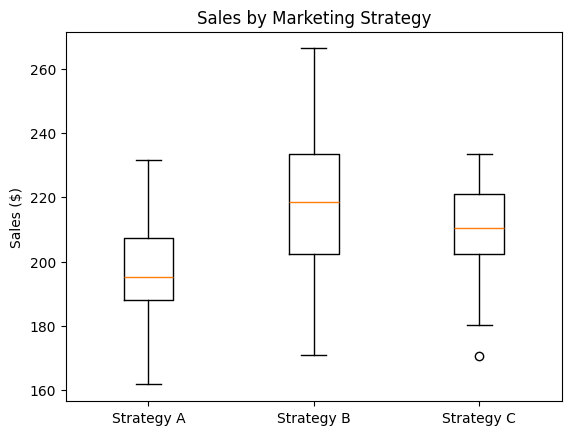

F-Statistic: 9.252
P-Value: 0.00023
Reject H₀: At least one strategy leads to different sales.


In [2]:

import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Simulated sales data for 3 marketing strategies
np.random.seed(42)
strategy_A = np.random.normal(loc=200, scale=20, size=30)
strategy_B = np.random.normal(loc=220, scale=25, size=30)
strategy_C = np.random.normal(loc=210, scale=15, size=30)

# Boxplot for visualization
plt.boxplot([strategy_A, strategy_B, strategy_C], tick_labels=["Strategy A", "Strategy B", "Strategy C"])
plt.title("Sales by Marketing Strategy")
plt.ylabel("Sales ($)")
plt.show()

# Perform One-Way ANOVA
f_stat, p_value = stats.f_oneway(strategy_A, strategy_B, strategy_C)

print(f"F-Statistic: {f_stat:.3f}")
print(f"P-Value: {p_value:.5f}")

# Decision
if p_value < 0.05:
    print("Reject H₀: At least one strategy leads to different sales.")
else:
    print("Fail to reject H₀: No significant difference in sales.")
    


📊 **Output Example**:  
- **F-Statistic**: 9.252  
- **p-Value**: 0.00023  

✅ **Interpretation**:  
✔ **p < 0.05** → Reject H₀ → At least one marketing strategy **performs differently**.  
✔ **p > 0.05** → Fail to reject H₀ → **No strong evidence** of a difference.  



---

# 🔄 **4. What If ANOVA is Significant? → Post-Hoc Tests**  

If ANOVA shows a significant result (**p < 0.05**), use **Post-Hoc Tests** to find **which specific groups differ**.

### 📌 **Tukey’s HSD (Honest Significant Difference) Test**  

In [3]:

import pandas as pd
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Prepare data for Tukey's test
sales_data = np.concatenate([strategy_A, strategy_B, strategy_C])
strategy_labels = ['A']*30 + ['B']*30 + ['C']*30

# Perform Tukey's HSD
tukey_result = pairwise_tukeyhsd(endog=sales_data, groups=strategy_labels, alpha=0.05)
print(tukey_result)


 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     A      B  20.7339 0.0002   9.0132 32.4546   True
     A      C  13.9562 0.0154   2.2355 25.6769   True
     B      C  -6.7777 0.3564 -18.4984   4.943  False
-----------------------------------------------------



✅ **Interpretation**:  
- **Strategy B** performs **significantly better** than **Strategy A**.  
- **Strategies A & C** and **B & C** show **no significant difference**.  



---

# ⚖️ **5. Assumptions of One-Way ANOVA**  

| **Assumption** | **How to Check?** | **Solution if Violated** |
|----------------|-------------------|--------------------------|
| **Independence of Observations** 📊 | Check data collection process | Ensure samples are independent |
| **Normality** 🔄 | Use **Shapiro-Wilk Test** or **Q-Q Plot** | Apply data transformation (e.g., log) |
| **Equal Variances (Homoscedasticity)** 📏 | Use **Levene’s Test** | Use **Welch’s ANOVA** if variances are unequal |

### 📌 **Example: Levene’s Test for Equal Variances**  
 


In [ ]:

stat, p_value = stats.levene(strategy_A, strategy_B, strategy_C)
print(f"\nLevene’s Test p-value: {p_value:.5f}")

if p_value > 0.05:
    print("\nVariances are equal. Proceed with ANOVA.")
else:
    print("\nVariances are NOT equal. Use Welch’s ANOVA.")



Levene’s Test p-value: 0.03368

Variances are NOT equal. Use Welch’s ANOVA.



---

# 📉 **6. When to Use One-Way ANOVA in Data Science?**  

📌 **Business & Marketing**  
✔ Comparing **sales across different campaigns**.  
✔ Evaluating **customer satisfaction across regions**.  

📌 **Machine Learning & Feature Engineering**  
✔ Testing if **categorical features impact target variables**.  
✔ Analyzing feature importance for model selection.  

📌 **Healthcare & Medicine**  
✔ Comparing **treatment effects across patient groups**.  
✔ Evaluating **average recovery times for different medications**.  

📌 **Finance & Economics**  
✔ Analyzing **investment returns across industries**.  
✔ Comparing **economic growth rates across countries**. 


---

# 🎯 **7. Summary: Key Takeaways on One-Way ANOVA**  

| **Feature**        | **Details**                           |
|-------------------|---------------------------------------|
| **Purpose**        | Compare means of **3 or more groups** |
| **Hypotheses**     | H₀: Means are equal<br>H₁: At least one mean differs |
| **Key Statistic**  | **F-Statistic**                      |
| **Significance**   | **p < 0.05 → Significant difference** |
| **Post-Hoc Tests** | **Tukey’s HSD** for pairwise comparisons |
| **Assumptions**    | Normality, equal variances, independence |

✅ **One-Way ANOVA** is a powerful tool for **comparing multiple groups** and identifying **key drivers** behind differences in data.  

---
